Using device: cuda
Classes: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 221MB/s]


Epoch 1/10 | Train Loss: 0.9241, Train Acc: 57.7% | Valid Loss: 0.6344, Valid Acc: 72.2%
Epoch 2/10 | Train Loss: 0.3360, Train Acc: 88.3% | Valid Loss: 0.3992, Valid Acc: 87.5%
Epoch 3/10 | Train Loss: 0.1390, Train Acc: 95.1% | Valid Loss: 0.3463, Valid Acc: 84.7%
Epoch 4/10 | Train Loss: 0.0448, Train Acc: 98.5% | Valid Loss: 0.2762, Valid Acc: 87.5%
Epoch 5/10 | Train Loss: 0.0428, Train Acc: 98.9% | Valid Loss: 0.4702, Valid Acc: 83.3%
Epoch 6/10 | Train Loss: 0.0191, Train Acc: 99.7% | Valid Loss: 0.2489, Valid Acc: 91.7%
Epoch 7/10 | Train Loss: 0.0130, Train Acc: 99.7% | Valid Loss: 0.3035, Valid Acc: 90.3%
Epoch 8/10 | Train Loss: 0.0160, Train Acc: 99.5% | Valid Loss: 0.2929, Valid Acc: 91.7%
Epoch 9/10 | Train Loss: 0.0142, Train Acc: 99.5% | Valid Loss: 0.3370, Valid Acc: 87.5%
Epoch 10/10 | Train Loss: 0.0188, Train Acc: 99.7% | Valid Loss: 0.3523, Valid Acc: 88.9%


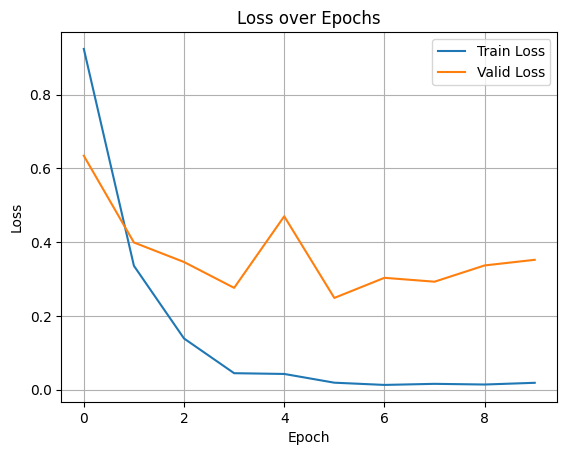

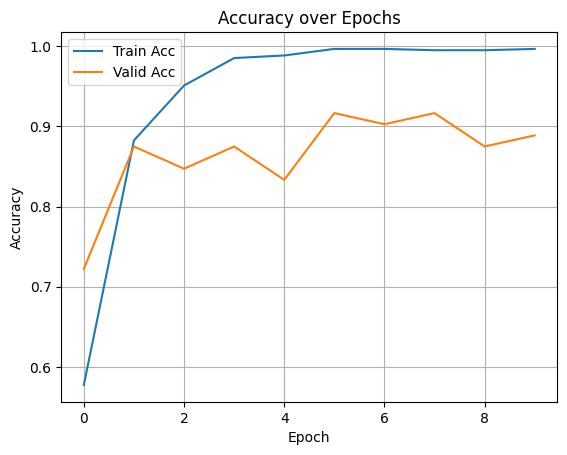


=== TRAIN SET REPORT ===
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       1.00      1.00      1.00       195
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       1.00      0.99      1.00       115
                                          normal       1.00      1.00      1.00       148
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.99      1.00      1.00       155

                                        accuracy                           1.00       613
                                       macro avg       1.00      1.00      1.00       613
                                    weighted avg       1.00      1.00      1.00       613


=== TEST SET REPORT ===
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.88      0.83      0.86       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_I

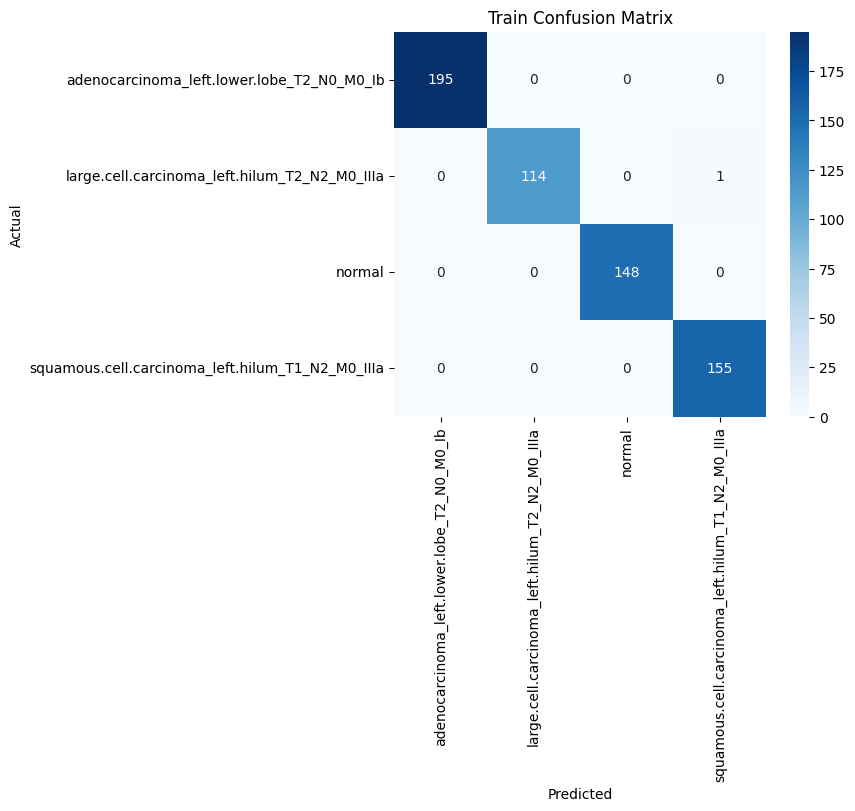

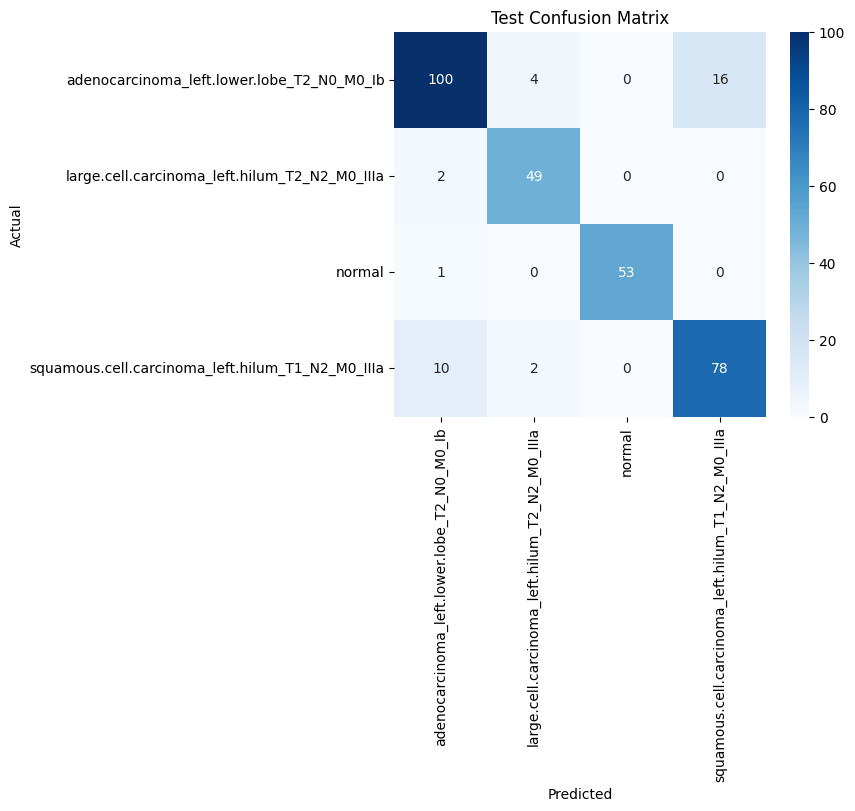

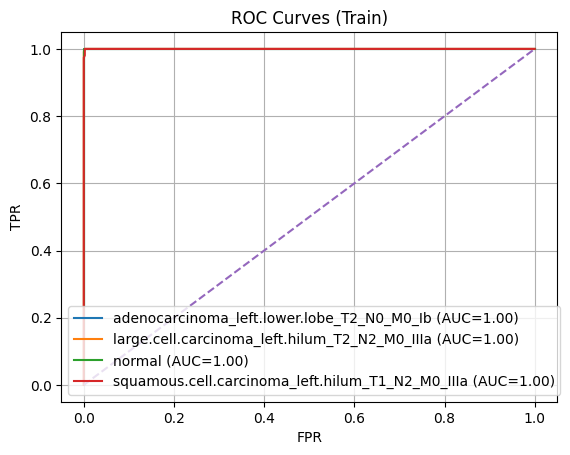

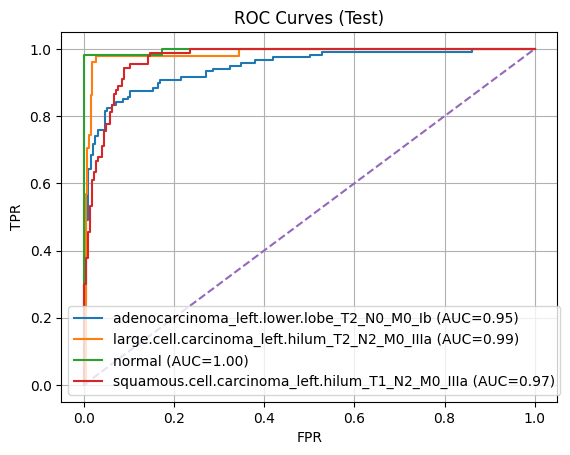

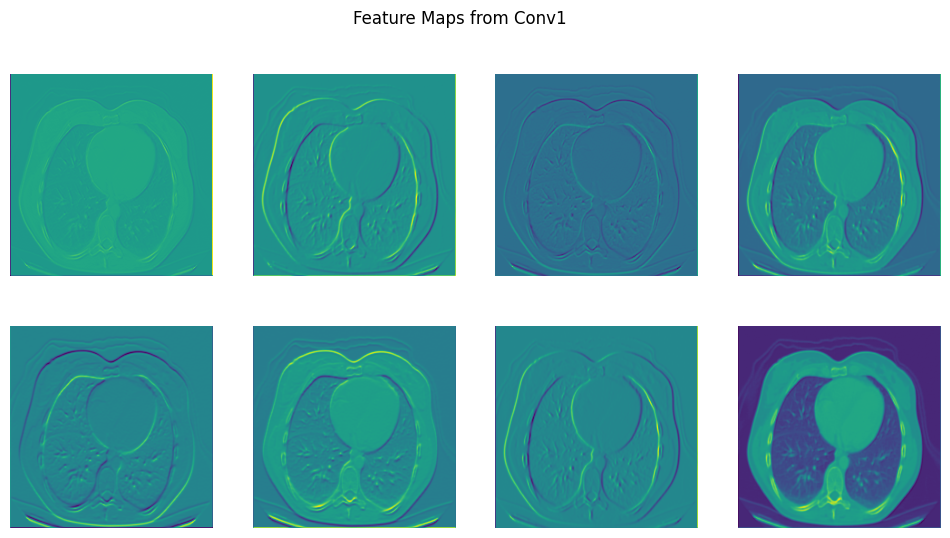

In [1]:
# ===== Import Required Libraries =====
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
import seaborn as sns
import numpy as np

# ===== Device Configuration =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===== Data Transformations =====
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# ===== Dataset Paths =====
base_dir   = '/kaggle/input/chest-ctscan-images/Data'
train_dir  = os.path.join(base_dir, 'train')
valid_dir  = os.path.join(base_dir, 'valid')
test_dir   = os.path.join(base_dir, 'test')

# ===== Load Datasets =====
train_ds = ImageFolder(train_dir, transform=transform)
valid_ds = ImageFolder(valid_dir, transform=transform)
test_ds  = ImageFolder(test_dir,  transform=transform)
class_names = train_ds.classes
print("Classes:", class_names)

# ===== DataLoaders =====
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

# ===== Load & Modify VGG16 =====
vgg16 = models.vgg16(pretrained=True)
for p in vgg16.features.parameters(): 
    p.requires_grad = False
num_ftrs = vgg16.classifier[-1].in_features
vgg16.classifier[-1] = nn.Linear(num_ftrs, len(class_names))
vgg16 = vgg16.to(device)

# ===== Loss & Optimizer =====
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, vgg16.parameters()), lr=1e-4)

# ===== Training & Evaluation Helpers =====
def train_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0., 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total   += y.size(0)
    return running_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    running_loss, correct, total = 0., 0, 0
    all_probs, all_preds, all_labels = [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)
        running_loss += loss.item() * x.size(0)
        prob = torch.softmax(out, dim=1)
        preds = prob.argmax(1)
        all_probs .append(prob.cpu())
        all_preds .append(preds.cpu())
        all_labels.append(y.cpu())
        correct += (preds == y).sum().item()
        total   += y.size(0)
    avg_loss = running_loss/total
    acc      = correct/total
    probs    = torch.cat(all_probs)
    preds    = torch.cat(all_preds)
    labels   = torch.cat(all_labels)
    return avg_loss, acc, preds, labels, probs

# ===== Training Loop =====
num_epochs = 10
train_losses, valid_losses = [], []
train_accs,   valid_accs   = [], []

for epoch in range(1, num_epochs+1):
    tl, ta = train_epoch(vgg16, train_loader)
    vl, va, _, _, _ = eval_epoch(vgg16, valid_loader)
    train_losses.append(tl); train_accs.append(ta)
    valid_losses.append(vl); valid_accs.append(va)
    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {tl:.4f}, Train Acc: {ta*100:.1f}% | "
          f"Valid Loss: {vl:.4f}, Valid Acc: {va*100:.1f}%")

# ===== Plot Loss & Accuracy Curves =====
plt.figure(); plt.plot(train_losses, label='Train Loss'); plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss over Epochs'); plt.grid(); plt.show()

plt.figure(); plt.plot(train_accs, label='Train Acc'); plt.plot(valid_accs, label='Valid Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Accuracy over Epochs'); plt.grid(); plt.show()

# ===== Final Metrics on Train & Test Sets =====
t_loss, t_acc, t_preds, t_labels, t_probs = eval_epoch(vgg16, train_loader)
v_loss, v_acc, v_preds, v_labels, v_probs = eval_epoch(vgg16, test_loader)

# Classification Reports
print("\n=== TRAIN SET REPORT ===")
print(classification_report(t_labels, t_preds, target_names=class_names))
print("\n=== TEST SET REPORT ===")
print(classification_report(v_labels, v_preds, target_names=class_names))

# Confusion Matrices
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(t_labels, t_preds), annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Train Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(v_labels, v_preds), annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Test Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

# ROC Curves
plt.figure()
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve((t_labels==i).numpy(), t_probs[:,i].numpy())
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves (Train)'); plt.legend(); plt.grid(); plt.show()

plt.figure()
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve((v_labels==i).numpy(), v_probs[:,i].numpy())
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
plt.plot([0,1],[0,1],'--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves (Test)'); plt.legend(); plt.grid(); plt.show()

# ===== Feature Map Visualization =====
feature_maps = []
def hook_fn(_, __, out):  # capture output of first conv
    feature_maps.append(out.cpu().detach())

# Register hook
vgg16.features[0].register_forward_hook(hook_fn)

# Pass a batch through to fill feature_maps
_ = vgg16(next(iter(test_loader))[0].to(device))

# Plot the first 8 channels of the first feature map
fm = feature_maps[0][0]  # first image in batch
plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(fm[i], cmap='viridis')
    plt.axis('off')
plt.suptitle('Feature Maps from Conv1'); plt.show()
